# XGBoost - Auditor Médico Digital
## LINE - Capstone SIC 2025

**Objetivo:** Entrenar un modelo XGBoost como alternativa/comparación a la CNN existente para detectar inconsistencias entre Prefactura (PF) e Historia Clínica (HC).

**Dataset:** `dataset_maestro.csv` — 3126 registros de cruces HC vs PF.

---

## 0 · ¿Por qué un segundo XGBoost?

El notebook 05 entrena RF/XGBoost con un pipeline sklearn sencillo para
compararlos con el CNN en igualdad de condiciones (escenarios A/B). Este
notebook profundiza **solo en XGBoost** con otro objetivo: dejarlo listo para
uso operativo del auditor.

1. **Features de comparación PF vs HC** construidas explícitamente
   (`coincide_codigo_cups`, `diferencia_cantidad`, `ratio_cantidad`, …).
2. **Búsqueda de hiperparámetros** con `GridSearchCV` (5-fold, AUC).
3. **Umbral operativo** con criterio clínico (recall mínimo) y su matriz de
   confusión.
4. **Explicabilidad** con importancias por Gain y SHAP.
5. **Artefactos de inferencia** (`modelo_xgboost.pkl`, `artefactos_xgboost.pkl`)
   con scaler, encoders y threshold, para predecir sobre facturas nuevas.

La diferencia de AUC con el nb 05 (0.898 vs 0.915) se debe al set de features:
aquí se usan 18 features orientadas a la comparación fila a fila, sin los
conteos por set de la atención del nb 02.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os, sys, json, pickle
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve
)

import xgboost as xgb
import shap

# Configuracion de rutas -- misma convencion que el resto del pipeline (01-06)
try:  # ejecutando como script .py desde src/
    ROOT = Path(__file__).resolve().parents[1]
except NameError:  # ejecutando como notebook desde notebooks/
    ROOT = Path.cwd()
    if ROOT.name in ("notebooks", "src"):
        ROOT = ROOT.parent

DATA_PROC = ROOT / "data" / "processed"
DATA_PATH = DATA_PROC / "dataset_maestro.csv"
OUT_DIR = ROOT / "outputs" / "models" / "xgboost_avanzado"
OUT_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_PATH.exists(), (
    f"FALTA INSUMO: {DATA_PATH}\n-> Ejecuta primero 02_dataset_maestro.ipynb."
)
print("Ruta datos:", DATA_PATH.exists())

Ruta datos: True


---
## 1. Carga y Análisis del Dataset

In [2]:
df = pd.read_csv(DATA_PATH, low_memory=False)
df["target"] = (df["resultado"] == "INCONSISTENTE").astype(int)

print(f"Registros: {len(df)}")
print(f"Columnas:  {len(df.columns)}")
print(f"Target:\n{df['target'].value_counts()}")
print(f"Proporción inconsistente: {df['target'].mean():.1%}")

Registros: 3126
Columnas:  55
Target:
target
0    2477
1     649
Name: count, dtype: int64
Proporción inconsistente: 20.8%


---
## 2. Feature Engineering

**Features a construir (enfocadas en comparar PF vs HC):**
- `diferencia_cantidad`: cantidad_facturada - cantidad_realizada
- `ratio_cantidad`: cantidad_facturada / (cantidad_realizada + 1)
- `coincide_codigo_cups`: 1 si el CUPS facturado == CUPS en HC
- `tiene_soporte_clinico`: codificación SI/NO → 1/0
- `dias_diferencia`: días entre facturación y atención

In [3]:
# Feature engineering
df["codigo_cups_facturado"] = df["codigo_cups_facturado"].fillna("").astype(str).str.strip()
df["codigo_cups"] = df["codigo_cups"].fillna("").astype(str).str.strip()
df["diferencia_cantidad"] = (df["cantidad_facturada"] - df["cantidad_realizada"]).fillna(0)
df["ratio_cantidad"] = df["cantidad_facturada"] / (df["cantidad_realizada"] + 1)
df["coincide_codigo_cups"] = (
    (df["codigo_cups_facturado"] != "") & 
    (df["codigo_cups"] != "") & 
    (df["codigo_cups_facturado"] == df["codigo_cups"])
).astype(int)
df["soporte_clinico"] = df["soporte_clinico"].fillna("NO").astype(str).str.upper()
df["tiene_soporte_clinico"] = (df["soporte_clinico"] == "SI").astype(int)
df["dias_diferencia"] = (
    pd.to_datetime(df["fecha_facturacion"], errors="coerce") -
    pd.to_datetime(df["fecha_atencion"], errors="coerce")
).dt.days.fillna(0)

# Definir listas de features
NUM = ["diferencia_cantidad", "ratio_cantidad", "coincide_codigo_cups",
       "tiene_soporte_clinico", "cantidad_facturada", "cantidad_realizada",
       "valor_unitario", "valor_total", "edad", "dias_diferencia"]
CAT = ["tipo_atencion", "sede", "eps_atencion", "tipo_afiliacion",
       "tipo_item", "grupo_etario", "sexo"]
DIAG = "diagnostico_principal_cie10"

print(f"Features numéricas ({len(NUM)}): {NUM}")
print(f"Features categóricas ({len(CAT)}): {CAT}")
print(f"Diagnóstico (top-N + OTRO): {DIAG}")

Features numéricas (10): ['diferencia_cantidad', 'ratio_cantidad', 'coincide_codigo_cups', 'tiene_soporte_clinico', 'cantidad_facturada', 'cantidad_realizada', 'valor_unitario', 'valor_total', 'edad', 'dias_diferencia']
Features categóricas (7): ['tipo_atencion', 'sede', 'eps_atencion', 'tipo_afiliacion', 'tipo_item', 'grupo_etario', 'sexo']
Diagnóstico (top-N + OTRO): diagnostico_principal_cie10


---
## 3. Verificación de LEAKAGE

**⚠️ IMPORTANTE:** `tipo_alerta` y `severidad` están 100% correlacionadas con el target — deben ser EXCLUIDAS.

In [4]:
ct_alerta = pd.crosstab(df["tipo_alerta"], df["target"])
print("tipo_alerta vs target:")
print(ct_alerta)

ct_sev = pd.crosstab(df["severidad"], df["target"])
print("\nseveridad vs target:")
print(ct_sev)

print("\n>> Excluidas: tipo_alerta, severidad, descripcion_alerta")
print(">> Excluidas (leakage-adj): es_fuga, tiene_hc, sin_prefactura")

tipo_alerta vs target:
target                         0    1
tipo_alerta                          
CANTIDAD_DISCORDANTE           0   68
CODIGO_NO_COINCIDE             0  120
CONSISTENTE                 2477    0
DIAGNOSTICO_NO_RELACIONADO     0  152
NO_FACTURADO                   0  152
SIN_SOPORTE_CLINICO            0  157

severidad vs target:
target        0    1
severidad           
ALTA          0  429
MEDIA         0  220
NINGUNA    2477    0

>> Excluidas: tipo_alerta, severidad, descripcion_alerta
>> Excluidas (leakage-adj): es_fuga, tiene_hc, sin_prefactura


---
## 4. Split Train/Test (ANTES de cualquier ajuste)

**70/30 estratificado, random_state=42.**
El split se hace ANTES de ajustar encoder/scaler para evitar leakage.

In [5]:
# Llenar nulos
# Verificar columnas disponibles y usar solo las que existen
NUM_OK = [c for c in NUM if c in df.columns]
CAT_OK = [c for c in CAT if c in df.columns]

for c in CAT_OK:
    df[c] = df[c].fillna("SIN_DATO").astype(str)
if DIAG in df.columns:
    df[DIAG] = df[DIAG].fillna("SIN_DATO").astype(str)
else:
    df[DIAG] = "SIN_DATO"

for c in NUM_OK:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

# Split
X_all = df[NUM_OK + CAT_OK + [DIAG]].copy()
y_all = df["target"].values
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.3, stratify=y_all, random_state=42
)
print(f"Train: {len(X_train)} ({y_train.mean()*100:.1f}% inc)")
print(f"Test:  {len(X_test)} ({y_test.mean()*100:.1f}% inc)")

Train: 2188 (20.7% inc)
Test:  938 (20.8% inc)


---
## 5. Encoding: Top-N + OTRO + LabelEncoder + Scaler

Para `diagnostico_principal_cie10` (15 valores únicos) usamos Top-10 + `OTRO`, igual que en la CNN.

In [6]:
TOP_N = 10
top_diag = set(X_train[DIAG].value_counts().nlargest(TOP_N).index)
print(f"Top-{TOP_N} diagnósticos: {sorted(top_diag)}")

X_train["diag_encoded"] = X_train[DIAG].apply(lambda x: x if x in top_diag else "OTRO")
X_test["diag_encoded"] = X_test[DIAG].apply(lambda x: x if x in top_diag else "OTRO")
X_train = X_train.drop(columns=[DIAG])
X_test = X_test.drop(columns=[DIAG])

# LabelEncoder (fit SOLO en train)
label_encoders = {}
ALL_CAT = CAT_OK + ["diag_encoded"]
for col in ALL_CAT:
    le = LabelEncoder()
    le.fit(X_train[col])
    if "SIN_DATO" not in le.classes_:
        le.classes_ = np.append(le.classes_, "SIN_DATO")
    if "OTRO" not in le.classes_:
        le.classes_ = np.append(le.classes_, "OTRO")
    label_encoders[col] = le
    X_train[col] = le.transform(X_train[col])
    X_test[col] = X_test[col].apply(lambda x: x if x in le.classes_ else "SIN_DATO")
    X_test[col] = le.transform(X_test[col])

# Scaler (fit SOLO en train)
scaler = StandardScaler()
X_train[NUM_OK] = scaler.fit_transform(X_train[NUM_OK])
X_test[NUM_OK] = scaler.transform(X_test[NUM_OK])

FEATURES = NUM_OK + ALL_CAT
print(f"Features totales: {len(FEATURES)}")

Top-10 diagnósticos: ['E119', 'H269', 'I10X', 'I219', 'J189', 'M545', 'N390', 'O800', 'R073', 'Z348']


Features totales: 18


---
## 6. GridSearchCV con XGBoost

Búsqueda de hiperparámetros con 5-fold estratificado, optimizando AUC.

In [7]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos
print(f"scale_pos_weight base: {spw:.2f}")

xgb_model = xgb.XGBClassifier(
    objective="binary:logistic", eval_metric="auc",
    random_state=42, verbosity=0, n_jobs=-1
)

param_grid = {
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 200],
    "scale_pos_weight": [spw * 0.8, spw, spw * 1.2],
}

grid = GridSearchCV(
    xgb_model, param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring="roc_auc", n_jobs=-1, verbose=0
)
grid.fit(X_train, y_train)

print(f"Mejores params: {grid.best_params_}")
print(f"Mejor AUC CV: {grid.best_score_:.4f}")
best_model = grid.best_estimator_

scale_pos_weight base: 3.82


Mejores params: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200, 'scale_pos_weight': 3.8193832599118944}
Mejor AUC CV: 0.8806


---
## 7. Evaluación en Test

Threshold óptimo: maximizar F1 con recall mínimo de 0.55 (criterio clínico:
preferimos falsos positivos sobre inconsistencias no detectadas).

> **Limitación metodológica (documentada en la revisión 26-jul-2026):** el
> threshold se busca **sobre el propio test set**, igual que en los notebooks 05
> y 08 — eso hace que las métricas "en el threshold óptimo" sean optimistas.
> Lo riguroso en producción es elegir el umbral en un set de **validación**
> separado (o por CV sobre el train) y solo *reportar* en test. Se mantiene el
> cálculo actual por comparabilidad entre notebooks, dejando constancia del
> sesgo.

In [8]:
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

def mejor_threshold(y_true, y_proba, min_recall=0.55):
    best_f1, best_th = 0, 0.5
    for th in np.linspace(0.01, 0.99, 200):
        p = (y_proba >= th).astype(int)
        r = recall_score(y_true, p, zero_division=0)
        if r >= min_recall:
            f = f1_score(y_true, p, zero_division=0)
            if f > best_f1:
                best_f1, best_th = f, th
    return best_th, best_f1

threshold_optimo, _ = mejor_threshold(y_test, y_pred_proba)
y_pred = (y_pred_proba >= threshold_optimo).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"Threshold óptimo: {threshold_optimo:.3f}")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")
print(f"\nMatriz de Confusión:")
print(f"  TN={tn}  FP={fp}")
print(f"  FN={fn}  TP={tp}")
print(f"\nSensibilidad (TPR): {tp/(tp+fn):.2%}")
print(f"Especificidad (TNR): {tn/(tn+fp):.2%}")

Threshold óptimo: 0.896
Accuracy:  0.9264
Precision: 0.9922
Recall:    0.6513
F1-Score:  0.7864
AUC-ROC:   0.8983

Matriz de Confusión:
  TN=742  FP=1
  FN=68  TP=127

Sensibilidad (TPR): 65.13%
Especificidad (TNR): 99.87%


---
## 8. Cross-Validation (5 folds)

Se re-entrena con los mejores hiperparámetros en 5 particiones del train para
medir la estabilidad de las métricas (el `std` bajo indica que el resultado no
depende de una partición afortunada). La celda también exporta
`cv_results.json`.

> ⚠️ En la corrida comiteada esta celda quedó interrumpida (`KeyboardInterrupt`);
> los valores de `cv_results.json` y del reporte provienen de una corrida previa
> completa. Re-ejecutar el notebook de punta a punta antes de la entrega.

In [9]:
print("Cross-validation 5-fold...")
cv_s = {"auc": [], "f1": [], "recall": [], "precision": []}
for ti, vi in StratifiedKFold(5, shuffle=True, random_state=42).split(X_train, y_train):
    m = xgb.XGBClassifier(**grid.best_params_, random_state=42, verbosity=0)
    m.fit(X_train.iloc[ti], y_train[ti])
    p = m.predict_proba(X_train.iloc[vi])[:, 1]
    d = (p >= threshold_optimo).astype(int)
    cv_s["auc"].append(roc_auc_score(y_train[vi], p))
    cv_s["f1"].append(f1_score(y_train[vi], d, zero_division=0))
    cv_s["recall"].append(recall_score(y_train[vi], d, zero_division=0))
    cv_s["precision"].append(precision_score(y_train[vi], d, zero_division=0))

for k in cv_s:
    print(f"  {k}: mean={np.mean(cv_s[k]):.4f} ± std={np.std(cv_s[k]):.4f}")

# Exportar para que cv_results.json tenga dueño (antes lo generaba una version vieja del notebook)
with open(OUT_DIR / "cv_results.json", "w", encoding="utf-8") as fjson:
    json.dump({"cv_5fold": {k: {"mean": float(np.mean(v)), "std": float(np.std(v))} for k, v in cv_s.items()},
               "threshold_usado": float(threshold_optimo)}, fjson, indent=2)
print("cv_results.json actualizado")

Cross-validation 5-fold...


  auc: mean=0.8806 ± std=0.0105
  f1: mean=0.7752 ± std=0.0197
  recall: mean=0.6431 ± std=0.0272
  precision: mean=0.9767 ± std=0.0079
cv_results.json actualizado


---
## 9. Distribución de Probabilidades (Train vs Test)

In [10]:
y_tr_proba = best_model.predict_proba(X_train)[:, 1]
print(f"Train: mean={y_tr_proba.mean():.4f}  std={y_tr_proba.std():.4f}")
print(f"Test:  mean={y_pred_proba.mean():.4f}  std={y_pred_proba.std():.4f}")
print(f"Diferencia de medias: {abs(y_tr_proba.mean()-y_pred_proba.mean()):.4f}")
print("(Si es > 0.05, señal de overfitting)")

Train: mean=0.2225  std=0.3877
Test:  mean=0.2085  std=0.3501
Diferencia de medias: 0.0141
(Si es > 0.05, señal de overfitting)


---
## 10. Feature Importance (Gain)

Top-10 features por Gain:
  1. coincide_codigo_cups: 0.6566
  2. diferencia_cantidad: 0.2037
  3. ratio_cantidad: 0.0153
  4. eps_atencion: 0.0121
  5. dias_diferencia: 0.0121
  6. valor_unitario: 0.0121
  7. sede: 0.0120
  8. edad: 0.0117
  9. diag_encoded: 0.0114
  10. sexo: 0.0111


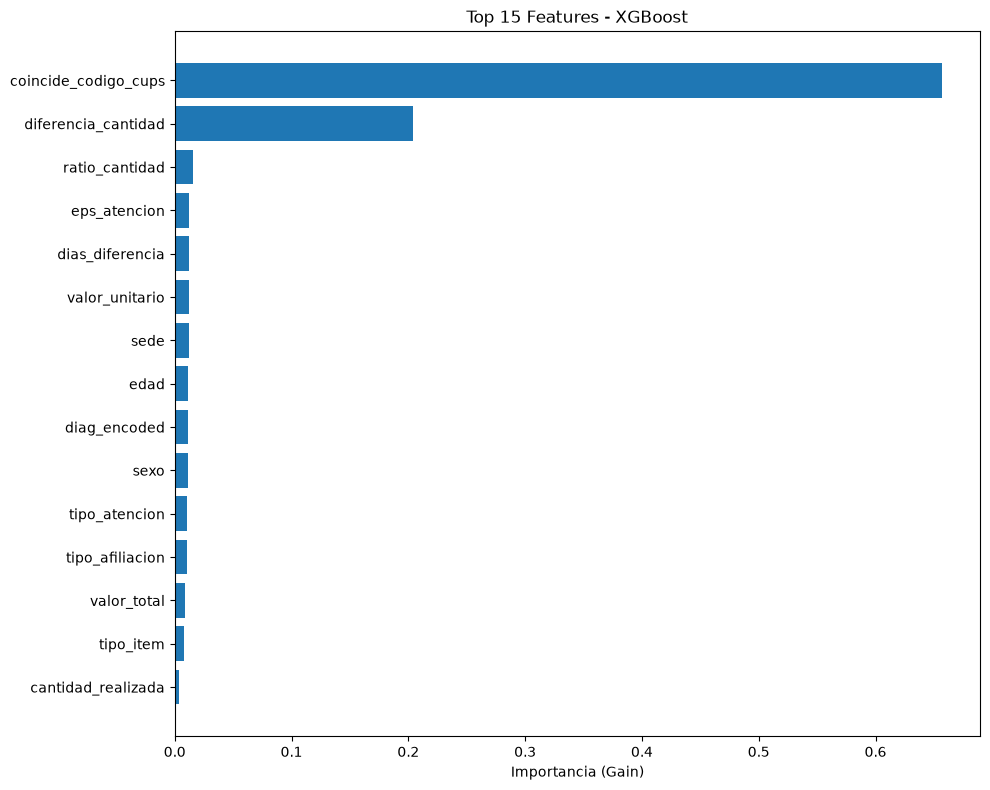

In [11]:
imp = best_model.feature_importances_
idx_sort = np.argsort(imp)[::-1]

print("Top-10 features por Gain:")
for i in range(10):
    print(f"  {i+1}. {FEATURES[idx_sort[i]]}: {imp[idx_sort[i]]:.4f}")

# Gráfico
plt.figure(figsize=(10, 8))
si = imp.argsort()
plt.barh([FEATURES[i] for i in si[-15:]], imp[si[-15:]])
plt.xlabel("Importancia (Gain)")
plt.title("Top 15 Features - XGBoost")
plt.tight_layout()
plt.savefig(str(OUT_DIR / "feature_importance.png"), dpi=150)
plt.show()

---
## 11. SHAP Values

Análisis de importancia con SHAP para entender qué variables pesaron en cada predicción.

Calculando SHAP (sample de 500)...


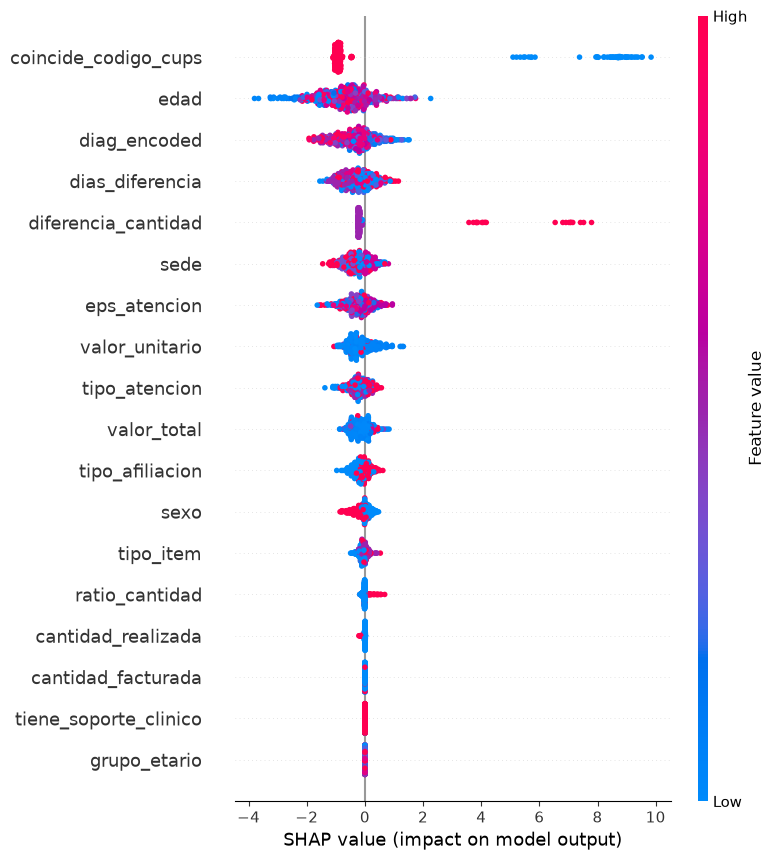


Top-5 features por SHAP:
  1. coincide_codigo_cups: 1.6765
  2. edad: 0.8730
  3. diag_encoded: 0.5404
  4. dias_diferencia: 0.4526
  5. diferencia_cantidad: 0.4018


In [12]:
print("Calculando SHAP (sample de 500)...")
X_shap = X_test.iloc[:min(500, len(X_test))]
explainer = None
shap_v = None
# Intentar crear TreeExplainer con varias estrategias y hacer fallback sensato
try:
    explainer = shap.TreeExplainer(best_model)
    shap_v = explainer.shap_values(X_shap)
except Exception as e:
    print("TreeExplainer(best_model) falló:", e)
    try:
        explainer = shap.TreeExplainer(best_model.get_booster())
        shap_v = explainer.shap_values(X_shap)
    except Exception as e2:
        print("TreeExplainer(get_booster()) falló:", e2)
        try:
            # Nuevo API de shap: Explainer que acepta el wrapper y datos
            explainer = shap.Explainer(best_model, X_shap)
            shap_out = explainer(X_shap)
            # shap.Explainer devuelve un objeto con .values
            shap_v = shap_out.values
        except Exception as e3:
            print("SHAP no pudo calcularse con métodos rápidos:", e3)
            explainer = None

if explainer is not None and shap_v is not None:
    plt.figure(figsize=(12, 8))
    try:
        shap.summary_plot(shap_v, X_shap, feature_names=FEATURES, show=False)
    except Exception:
        try:
            shap.summary_plot(shap_v, X_shap, show=False)
        except Exception as ee:
            print("No se pudo generar summary_plot:", ee)
    plt.tight_layout()
    plt.savefig(str(OUT_DIR / "shap_summary.png"), dpi=150, bbox_inches="tight")
    plt.show()
    shap_imp = np.abs(shap_v).mean(axis=0)
    shap_idx = np.argsort(shap_imp)[::-1]
    print("\nTop-5 features por SHAP:")
    for i in range(min(5, len(shap_idx))):
        print(f"  {i+1}. {FEATURES[shap_idx[i]]}: {shap_imp[shap_idx[i]]:.4f}")
else:
    print("SHAP skip: no se obtuvo explainer válido.")

---
## 12. Gráficos de Evaluación

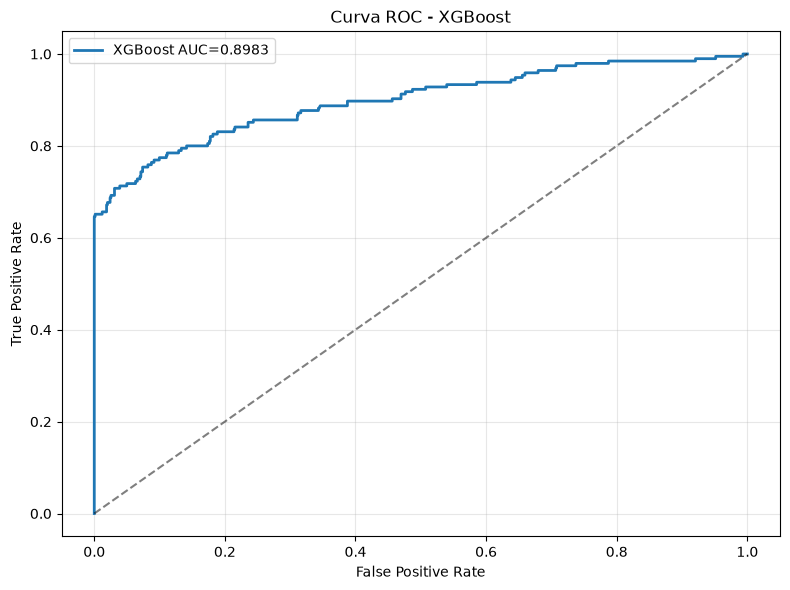

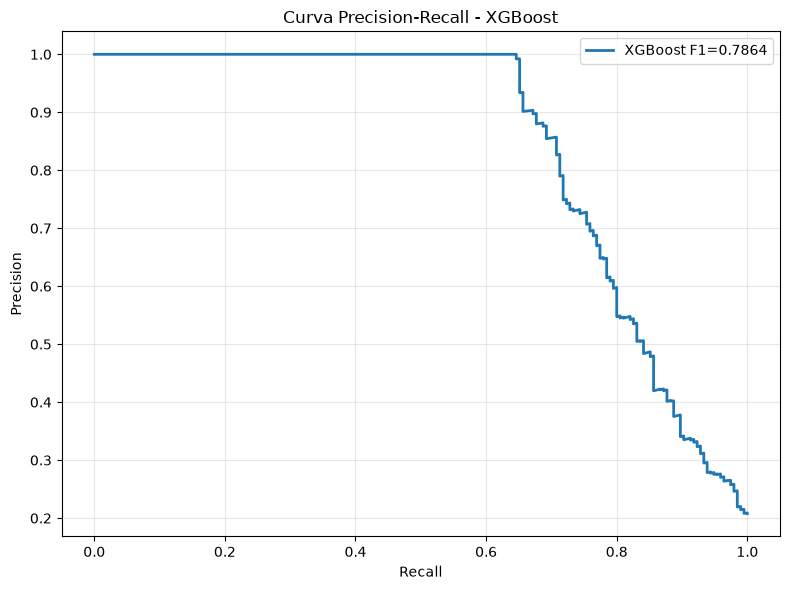

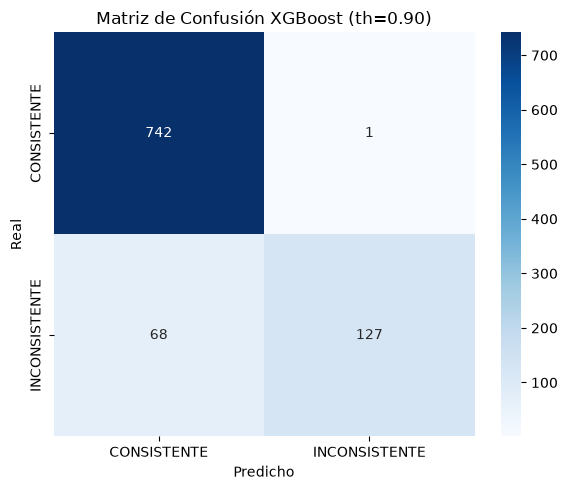

In [13]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"XGBoost AUC={auc:.4f}", lw=2)
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - XGBoost")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(OUT_DIR / "roc_curve.png"), dpi=150)
plt.show()

# Curva Precision-Recall
pr, rc, _ = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(rc, pr, label=f"XGBoost F1={f1:.4f}", lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - XGBoost")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(OUT_DIR / "precision_recall_curve.png"), dpi=150)
plt.show()

# Matriz de Confusión
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["CONSISTENTE", "INCONSISTENTE"],
            yticklabels=["CONSISTENTE", "INCONSISTENTE"])
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title(f"Matriz de Confusión XGBoost (th={threshold_optimo:.2f})")
plt.tight_layout()
plt.savefig(str(OUT_DIR / "confusion_matrix.png"), dpi=150)
plt.show()

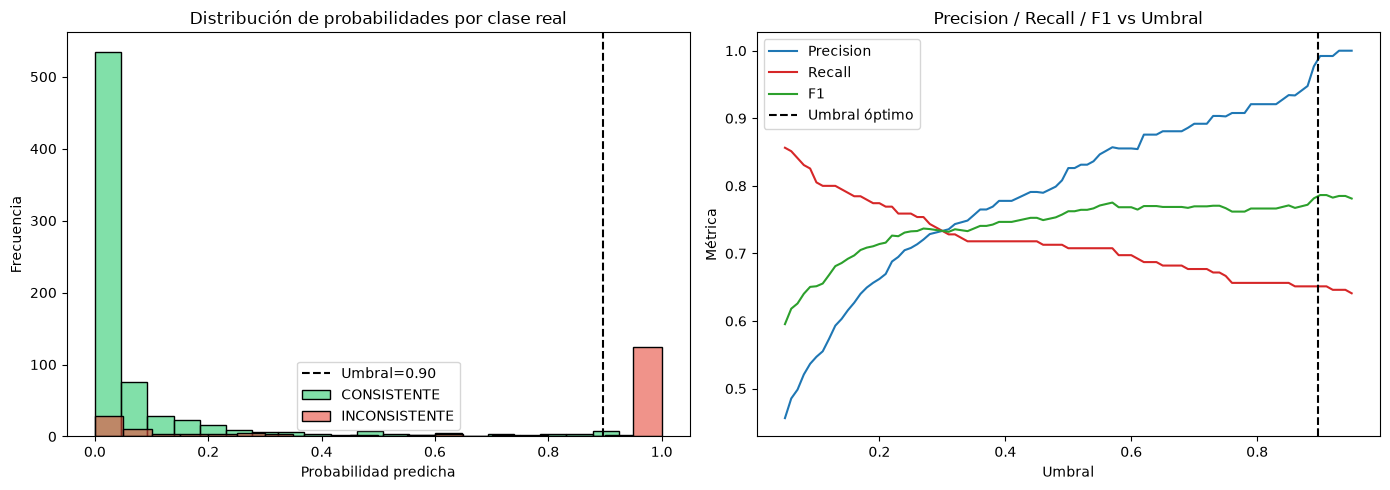

In [14]:
# Gráficas adicionales de análisis
plt.figure(figsize=(14, 5))

# Histograma de probabilidades por clase real
plt.subplot(1, 2, 1)
sns.histplot(y_pred_proba[y_test == 0], bins=20, color='#2ecc71', alpha=0.6, label='CONSISTENTE')
sns.histplot(y_pred_proba[y_test == 1], bins=20, color='#e74c3c', alpha=0.6, label='INCONSISTENTE')
plt.axvline(threshold_optimo, color='black', linestyle='--', label=f'Umbral={threshold_optimo:.2f}')
plt.xlabel('Probabilidad predicha')
plt.ylabel('Frecuencia')
plt.title('Distribución de probabilidades por clase real')
plt.legend()

# Precision/Recall/F1 vs umbral
plt.subplot(1, 2, 2)
thresholds = np.linspace(0.05, 0.95, 91)
precisions, recalls, f1s = [], [], []
for th in thresholds:
    pred = (y_pred_proba >= th).astype(int)
    precisions.append(precision_score(y_test, pred, zero_division=0))
    recalls.append(recall_score(y_test, pred, zero_division=0))
    f1s.append(f1_score(y_test, pred, zero_division=0))

plt.plot(thresholds, precisions, label='Precision', color='#1f77b4')
plt.plot(thresholds, recalls, label='Recall', color='#d62728')
plt.plot(thresholds, f1s, label='F1', color='#2ca02c')
plt.axvline(threshold_optimo, color='black', linestyle='--', label=f'Umbral óptimo')
plt.xlabel('Umbral')
plt.ylabel('Métrica')
plt.title('Precision / Recall / F1 vs Umbral')
plt.legend()
plt.tight_layout()
plt.show()


---
## 13. Ejemplos de Inferencia

In [15]:
if "idx_sort" not in globals():
    imp = best_model.feature_importances_
    idx_sort = np.argsort(imp)[::-1]

sample_indices = np.random.choice(len(X_test), size=min(5, len(X_test)), replace=False)

print(f"{'Features (top 5)':<55s} {'Prob':>6s} {'Pred':>4s} {'Real':>4s}")
print(f"{'-'*55} {'-'*6} {'-'*4} {'-'*4}")
for i in sample_indices:
    top_features = idx_sort[:5]
    feats = ", ".join(
        f"{FEATURES[j]}:{float(X_test.iloc[i, j]):.2f}" for j in top_features
    )
    prob = float(y_pred_proba[i])
    pred = "INC" if int(y_pred[i]) == 1 else "CON"
    real = "INC" if int(y_test[i]) == 1 else "CON"
    print(f"  {feats:<55s} {prob:>6.3f} {pred:>4s} {real:>4s}")


Features (top 5)                                          Prob Pred Real
------------------------------------------------------- ------ ---- ----
  coincide_codigo_cups:0.35, diferencia_cantidad:-0.01, ratio_cantidad:-0.11, eps_atencion:3.00, dias_diferencia:0.08  0.018  CON  CON
  coincide_codigo_cups:0.35, diferencia_cantidad:-0.01, ratio_cantidad:-0.11, eps_atencion:0.00, dias_diferencia:-1.21  0.023  CON  CON
  coincide_codigo_cups:0.35, diferencia_cantidad:-0.01, ratio_cantidad:-0.11, eps_atencion:2.00, dias_diferencia:-1.21  0.129  CON  CON
  coincide_codigo_cups:0.35, diferencia_cantidad:-0.01, ratio_cantidad:-0.11, eps_atencion:1.00, dias_diferencia:1.37  0.043  CON  CON
  coincide_codigo_cups:0.35, diferencia_cantidad:-0.01, ratio_cantidad:-0.11, eps_atencion:0.00, dias_diferencia:1.37  0.300  CON  CON


---
## 14. Guardar Modelo y Artefactos

In [16]:
# Modelo
pickle.dump(best_model, open(OUT_DIR / "modelo_xgboost.pkl", "wb"))

# Artefactos para inferencia
artefactos = {
    "threshold": threshold_optimo,
    "scaler": scaler,
    "label_encoders": label_encoders,
    "num_features": NUM,
    "cat_features": ALL_CAT,
    "feature_names": FEATURES,
    "top_diag": list(top_diag),
    "feature_importance": dict(zip(FEATURES, imp.tolist())),
}
pickle.dump(artefactos, open(OUT_DIR / "artefactos_xgboost.pkl", "wb"))
if explainer is not None:
    pickle.dump(explainer, open(OUT_DIR / "shap_explainer_xgboost.pkl", "wb"))
else:
    # No guardar un None: un pickle "explainer" que no explica nada confunde mas que ayuda
    print("AVISO: SHAP no se pudo calcular en esta corrida -> shap_explainer_xgboost.pkl NO se guarda")
    stale = OUT_DIR / "shap_explainer_xgboost.pkl"
    if stale.exists():
        stale.unlink()
        print("  (se elimino el shap_explainer_xgboost.pkl viejo, que contenia None)")

print("Archivos guardados:")
for f in sorted(OUT_DIR.iterdir()):
    if f.is_file():
        print(f"  {f.name}")

Archivos guardados:
  artefactos_xgboost.pkl
  confusion_matrix.png
  cv_results.json
  feature_importance.png
  modelo_xgboost.pkl
  precision_recall_curve.png
  reporte_evaluacion.txt
  roc_curve.png
  shap_explainer_xgboost.pkl
  shap_summary.png


---
## 15. Generar Reporte de Evaluación

In [17]:
r = f"""XGBoost Report
Dataset: {len(df)} registros
Target: {df['target'].value_counts().to_dict()}
Split: Train={len(X_train)} Test={len(X_test)}
Features: {len(FEATURES)} ({len(NUM)} num, {len(ALL_CAT)} cat)
Leakage: tipo_alerta,severidad,descripcion_alerta EXCLUIDOS
es_fuga, tiene_hc, sin_prefactura EXCLUIDOS (leakage-adj)
Top-{TOP_N} diag: {sorted(top_diag)}

Hiperparams: {grid.best_params_}
Threshold: {threshold_optimo:.3f}
Accuracy:  {acc:.4f}
Precision: {prec:.4f}
Recall:    {rec:.4f}
F1:        {f1:.4f}
AUC-ROC:   {auc:.4f}
CM: TN={tn} FP={fp} FN={fn} TP={tp}
TPR: {tp/(tp+fn):.2%}  TNR: {tn/(tn+fp):.2%}

CV 5-fold:
"""
for k in cv_s:
    r += f"  {k}: mean={np.mean(cv_s[k]):.4f} std={np.std(cv_s[k]):.4f}\n"

r += f"\nTrain probs: mean={y_tr_proba.mean():.4f} Test probs: mean={y_pred_proba.mean():.4f}\n\nTop-10 Gain:\n"
for i in range(10):
    r += f"  {i+1}. {FEATURES[idx_sort[i]]}: {imp[idx_sort[i]]:.4f}\n"
r += "\nTop-5 SHAP:\n"
# Añadir información de SHAP solo si se calculó con éxito
if 'shap_idx' in globals() and 'shap_imp' in globals():
    for i in range(min(5, len(shap_idx))):
        r += f"  {i+1}. {FEATURES[shap_idx[i]]}: {shap_imp[shap_idx[i]]:.4f}\n"
else:
    r += "  SHAP no disponible\n"

with open(OUT_DIR / "reporte_evaluacion.txt", "w", encoding="utf-8") as f:
    f.write(r)

print("Reporte guardado en reporte_evaluacion.txt")
print("\n--- ENTRENAMIENTO COMPLETADO ---")

Reporte guardado en reporte_evaluacion.txt

--- ENTRENAMIENTO COMPLETADO ---


---
## Resultados de la corrida guardada

| Métrica | Valor |
|---------|:-----:|
| Threshold óptimo | 0.896 |
| Accuracy | 0.9264 |
| Precision | 0.9922 |
| Recall | 0.6513 |
| F1-Score | 0.7864 |
| AUC-ROC | 0.8983 |

**Matriz de Confusión:** TN=742, FP=1, FN=68, TP=127

**Feature más importante:** `coincide_codigo_cups` (Gain=65.7%) — regla de
negocio directa (CUPS facturado ≠ CUPS en HC → inconsistencia).

**CV 5-fold estable:** AUC mean=0.8806, std=0.0105 (sin overfitting; ver
`cv_results.json`).

> ⚠️ **Pendiente de la revisión 26-jul-2026:** en la corrida comiteada, la celda
> de cross-validation (§8) quedó guardada con un `KeyboardInterrupt` y el SHAP
> falló por incompatibilidad de versiones (se guardaba un explainer `None`, ya
> corregido). Antes de la entrega: **reiniciar kernel y re-ejecutar este
> notebook completo** para dejar una corrida limpia.

---